In [ ]:
#Exploratory Data Analysis of the WESAD dataset

#For the initial analysis we are first inspecting a single subject (S2)

#This notebook focuses on one subject to develop intuition before extending the analysis to the entire dataset

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [3]:
subject = "S2"

with open(f"../data/raw/{subject}/{subject}.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

In [4]:
data.keys()

dict_keys(['signal', 'label', 'subject'])

In [5]:
data["signal"].keys()

dict_keys(['chest', 'wrist'])

In [6]:
data["signal"]["chest"].keys()

dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])

In [7]:
data["signal"]["wrist"].keys()

dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])

In [ ]:
for name, signal in data["signal"]["chest"].items():
    print(name, signal.shape)

ACC (4255300, 3)
ECG (4255300, 1)
EMG (4255300, 1)
EDA (4255300, 1)
Temp (4255300, 1)
Resp (4255300, 1)


In [ ]:
for name, signal in data["signal"]["wrist"].items():
    print(name, signal.shape)

ACC (194528, 3)
BVP (389056, 1)
EDA (24316, 1)
TEMP (24316, 1)


In [ ]:
labels = data["label"]

unique, counts = np.unique(labels, return_counts=True)

pd.DataFrame({
    "Label": unique,
    "Count": counts
})

,Label,Count
0,0,2142701
1,1,800800
2,2,430500
3,3,253400
4,4,537599
5,6,45500
6,7,44800


In [ ]:
pd.DataFrame({
    "Label": unique,
    "Count": counts,
    "Percentage": counts/len(labels)*100
})

,Label,Count,Percentage
0,0,2142701,50.353700
1,1,800800,18.818885
2,2,430500,10.116796
3,3,253400,5.954927
4,4,537599,12.633633
5,6,45500,1.069255
6,7,44800,1.052805


In [ ]:
fs = 700
samples = 60 * fs

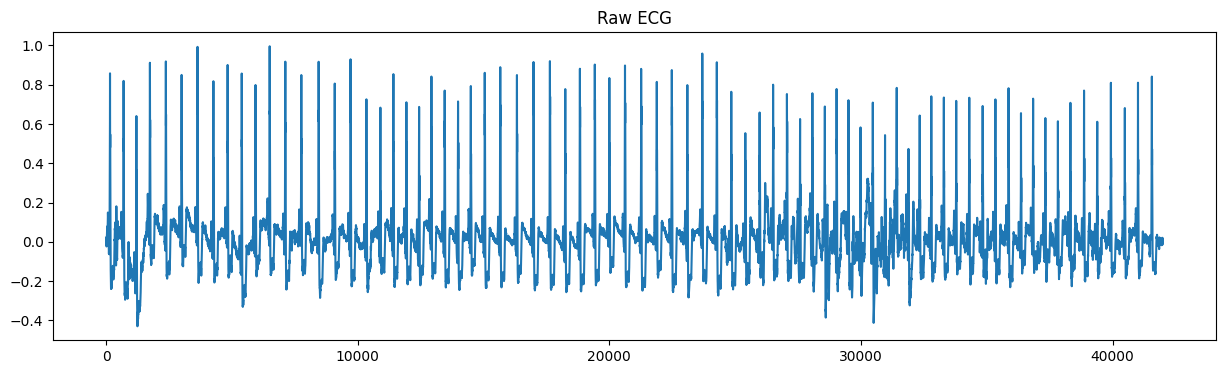

In [ ]:
plt.figure(figsize=(15,4))
plt.plot(data["signal"]["chest"]["ECG"][:samples])
plt.title("Raw ECG")
plt.show()

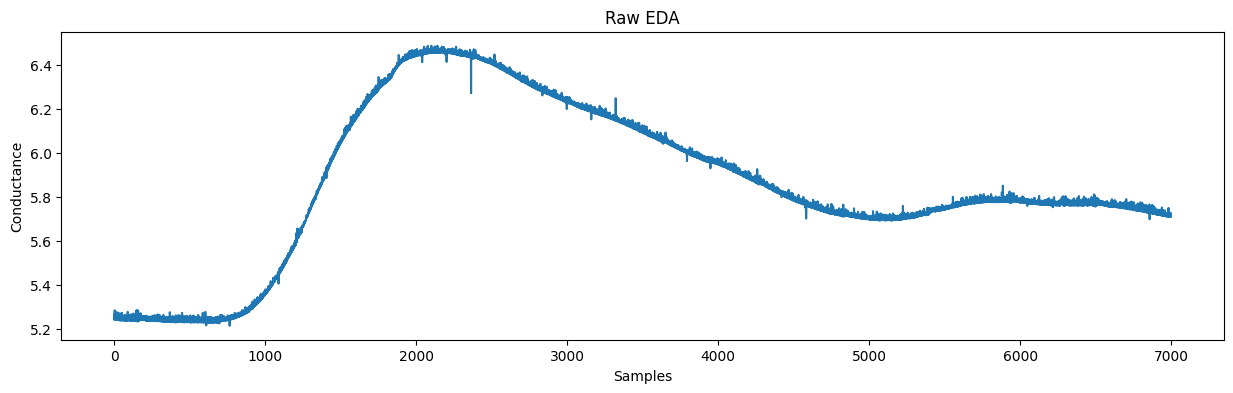

In [ ]:
eda = data["signal"]["chest"]["EDA"].squeeze()

plt.figure(figsize=(15,4))
plt.plot(eda[:samples])
plt.title("Raw EDA")
plt.xlabel("Samples")
plt.ylabel("Conductance")
plt.show()

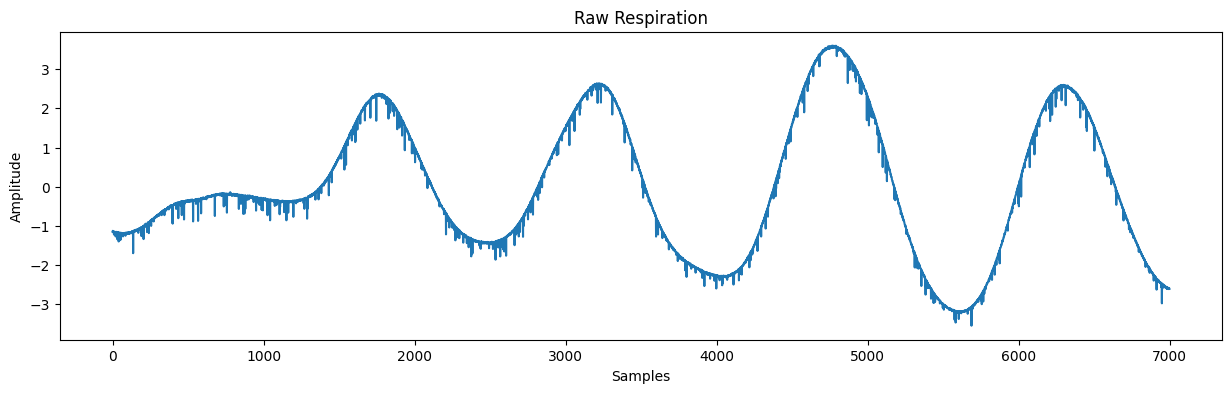

In [ ]:
resp = data["signal"]["chest"]["Resp"].squeeze()

plt.figure(figsize=(15,4))
plt.plot(resp[:samples])
plt.title("Raw Respiration")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

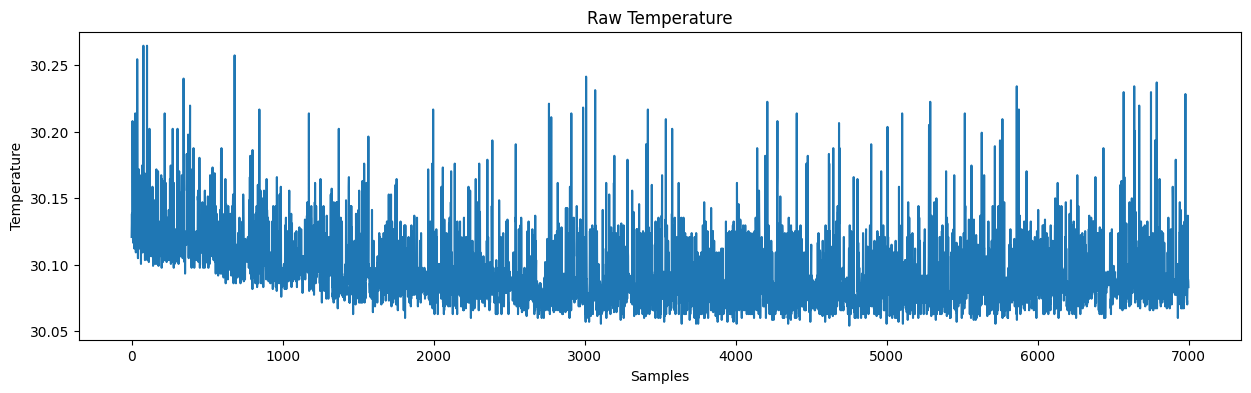

In [ ]:
temp = data["signal"]["chest"]["Temp"].squeeze()

plt.figure(figsize=(15,4))
plt.plot(temp[:samples])
plt.title("Raw Temperature")
plt.xlabel("Samples")
plt.ylabel("Temperature")
plt.show()

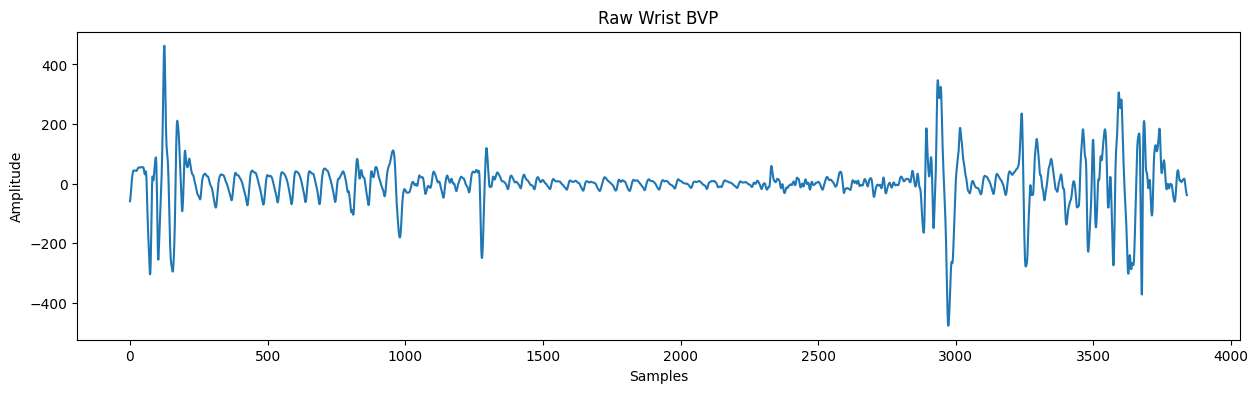

In [10]:
bvp = data["signal"]["wrist"]["BVP"].squeeze()

fs_wrist = 64
samples = 60 * fs_wrist

plt.figure(figsize=(15,4))
plt.plot(bvp[:samples])
plt.title("Raw Wrist BVP")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

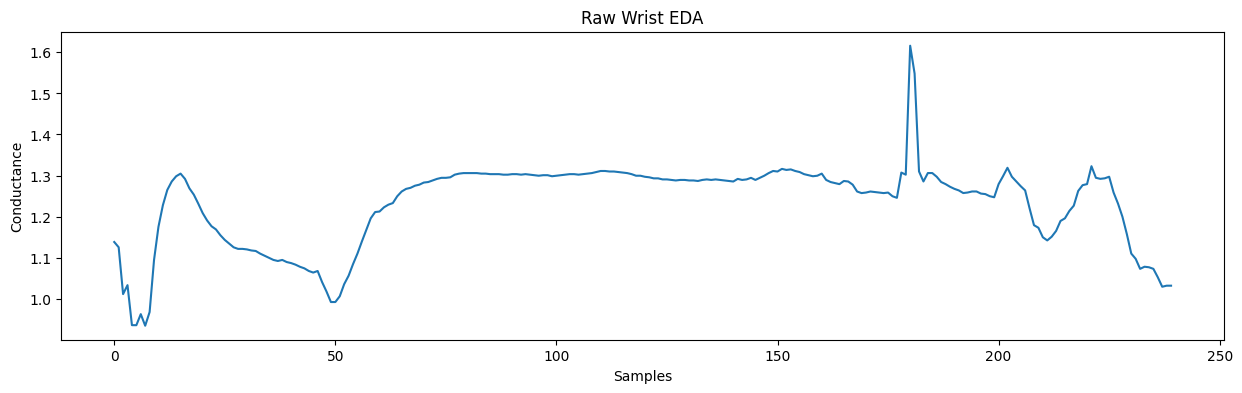

In [13]:
wrist_eda = data["signal"]["wrist"]["EDA"].squeeze()

fs_wrist_eda = 4          # 4 samples per second
duration = 60             # first 60 seconds
samples = fs_wrist_eda * duration

plt.figure(figsize=(15,4))
plt.plot(wrist_eda[:samples])

plt.title("Raw Wrist EDA")
plt.xlabel("Samples")
plt.ylabel("Conductance")

plt.show()

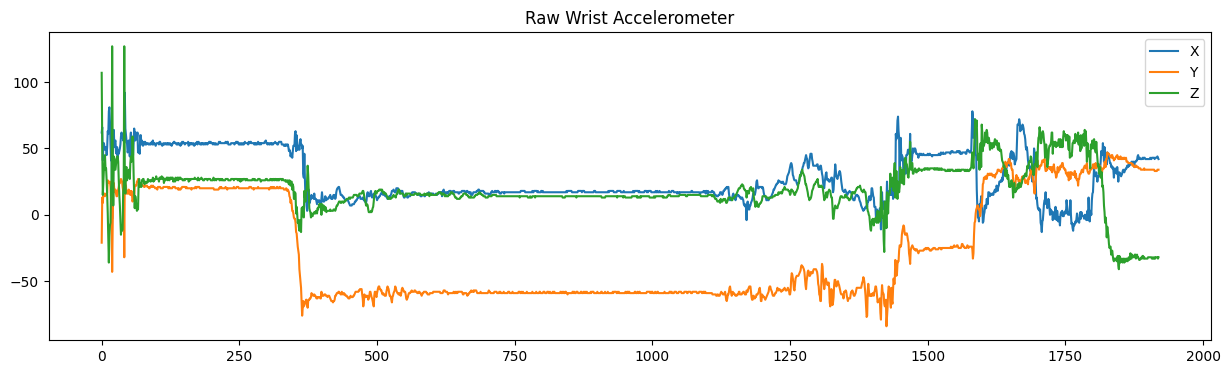

In [12]:
acc = data["signal"]["wrist"]["ACC"]

plt.figure(figsize=(15,4))
plt.plot(acc[:32*60,0], label="X")
plt.plot(acc[:32*60,1], label="Y")
plt.plot(acc[:32*60,2], label="Z")
plt.legend()
plt.title("Raw Wrist Accelerometer")
plt.show()

In [ ]:
baseline_idx = np.where(labels == 1)[0]
stress_idx = np.where(labels == 2)[0]

Text(0, 0.5, 'Amplitude')

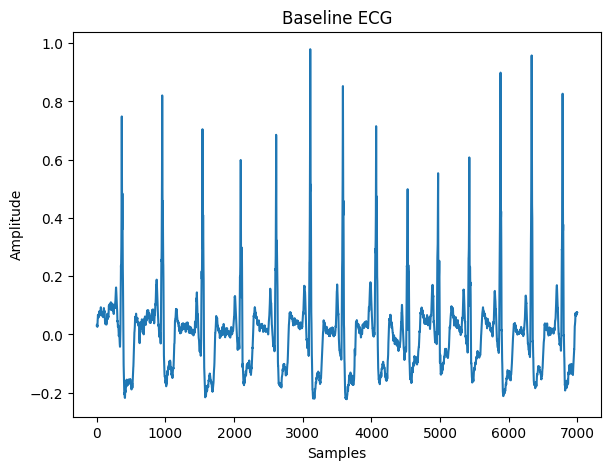

In [ ]:
fs = 700
duration = 10  # seconds
samples = fs * duration

ecg = data["signal"]["chest"]["ECG"].squeeze()

# Baseline ECG
baseline_start = baseline_idx[0]

# Stress ECG
stress_start = stress_idx[0]

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.plot(ecg[baseline_start:baseline_start+samples])
plt.title("Baseline ECG")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

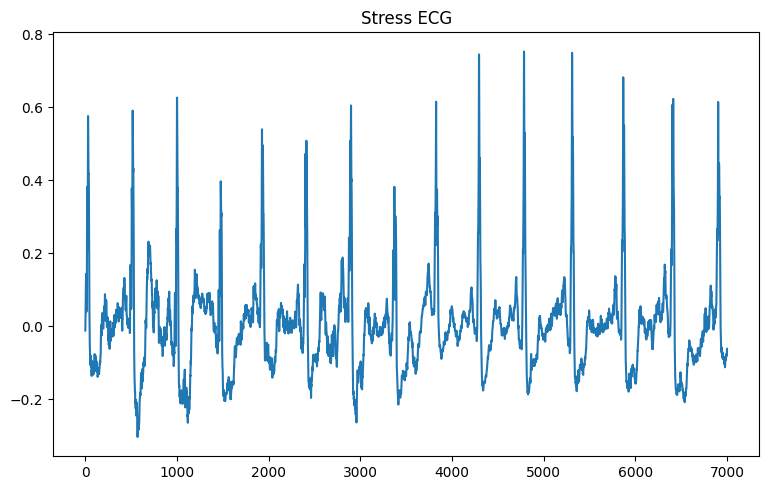

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(ecg[stress_start:stress_start+samples])
plt.title("Stress ECG")

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Conductance')

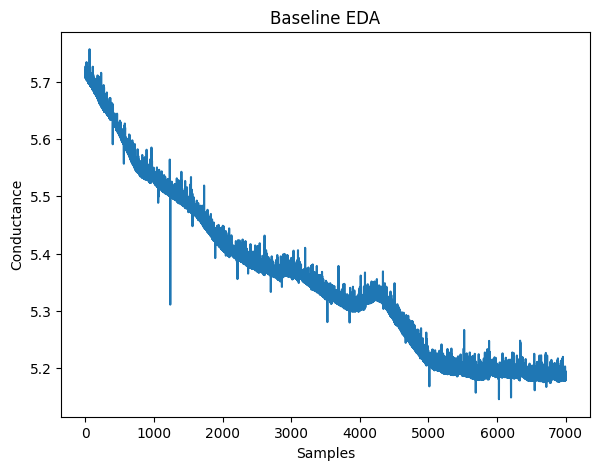

In [ ]:
eda = data["signal"]["chest"]["EDA"].squeeze()

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.plot(eda[baseline_start:baseline_start+samples])
plt.title("Baseline EDA")
plt.xlabel("Samples")
plt.ylabel("Conductance")



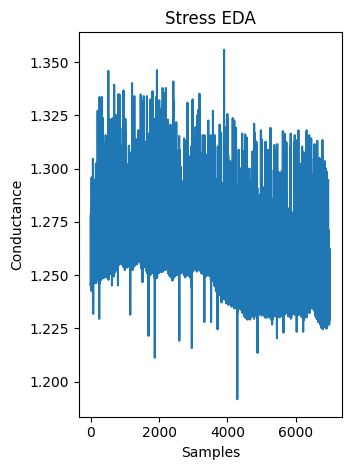

In [ ]:
plt.subplot(1,2,2)
plt.plot(eda[stress_start:stress_start+samples])
plt.title("Stress EDA")
plt.xlabel("Samples")
plt.ylabel("Conductance")

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Amplitude')

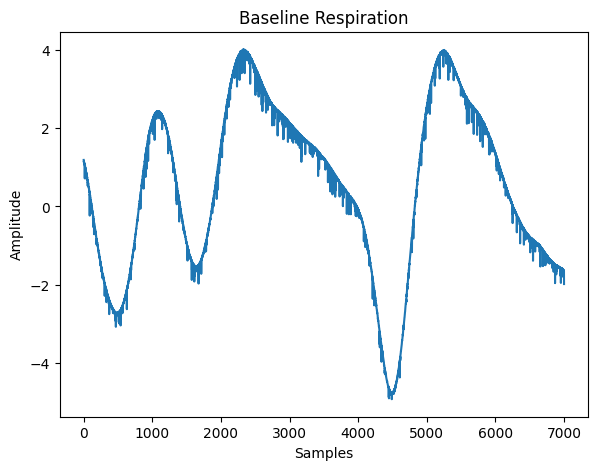

In [ ]:
resp = data["signal"]["chest"]["Resp"].squeeze()

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.plot(resp[baseline_start:baseline_start+samples])
plt.title("Baseline Respiration")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

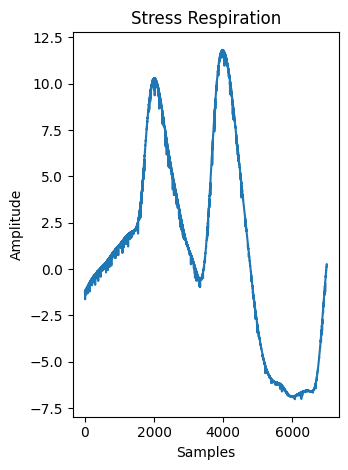

In [ ]:
plt.subplot(1,2,2)
plt.plot(resp[stress_start:stress_start+samples])
plt.title("Stress Respiration")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Temperature')

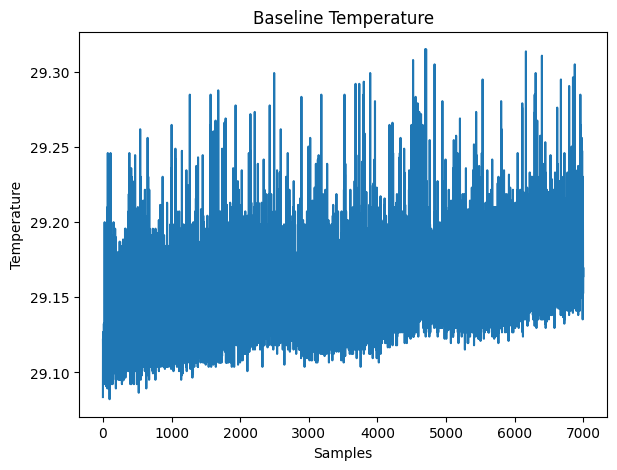

In [ ]:
temp = data["signal"]["chest"]["Temp"].squeeze()

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.plot(temp[baseline_start:baseline_start+samples])
plt.title("Baseline Temperature")
plt.xlabel("Samples")
plt.ylabel("Temperature")

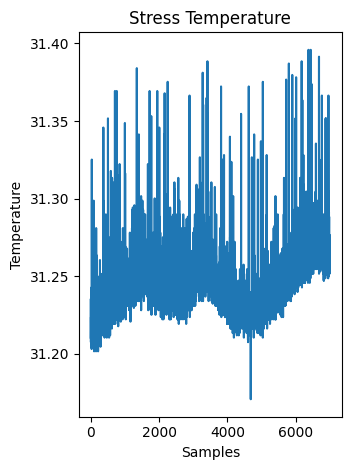

In [ ]:
plt.subplot(1,2,2)
plt.plot(temp[stress_start:stress_start+samples])
plt.title("Stress Temperature")
plt.xlabel("Samples")
plt.ylabel("Temperature")

plt.tight_layout()
plt.show()